In [2]:
%load_ext autoreload
%autoreload 2
%cd ..

/home/gasparyanartur/dev/brain-image-implementation


In [3]:
import logging
logging.basicConfig(level=logging.INFO)

In [4]:
from pathlib import Path

from brain_image.model import EEGAlignmentModel

cp_path = Path("logs/nice/version_120/checkpoints/nice-epoch=02-VAL__loss=0.1317.ckpt")

import torch
from lightning import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint


device = "cuda"
dtype = torch.float32

model = EEGAlignmentModel.load_checkpoint(cp_path, undo_compile=True, preload_latents=False).to(device, dtype=dtype)

In [5]:
from brain_image.utils import investigate_tensor


model.eval()
model.set_mode("val")

tensor_cache = model.tensor_cache

val_dataloader = model.val_dataloader()
img_paths = []
all_eeg_datas_ = []
all_aligned_latents_ = []
all_high_clip_latents_ = []
all_used_high_clip_latents_ = []

for batch_idx , batch in enumerate(val_dataloader):
    prepped_batch = model.prepare_batch(batch, batch_idx, "val")
    img_paths.extend(batch["img_path"])
    all_eeg_datas_.extend(batch["eeg_data"])
    all_aligned_latents_.extend(model._get_batch_from_cache(batch["img_path"], "align", model.config.align_target_model, "test"))
    all_high_clip_latents_.extend(model._get_batch_from_cache(batch["img_path"], "recon", model.config.high_recon_model, "test"))
    all_used_high_clip_latents_.extend(batch["high_recon_image_latent"])

all_eeg_datas = torch.stack(all_eeg_datas_)
all_aligned_latents = torch.stack(all_aligned_latents_)
all_high_clip_latents = torch.stack(all_high_clip_latents_)
all_used_high_clip_latents = torch.stack(all_used_high_clip_latents_)

investigate_tensor("all_eeg_datas", all_eeg_datas)
investigate_tensor("all_aligned_latents", all_aligned_latents)
investigate_tensor("all_high_clip_latents", all_high_clip_latents)
investigate_tensor("all_used_high_clip_latents", all_used_high_clip_latents)

investigate_tensor("all_high_clip_latents (256)", all_high_clip_latents[:256])

/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Name: all_eeg_datas
* shape: (2000, 17, 100)
* dtype: torch.float32
* norm: 2.273
* min: -0.508
* max: 0.442
* mean: -0.054
* std: 0.214
Name: all_aligned_latents
* shape: (2000, 768)
* dtype: torch.float32
* norm: 14.730
* min: -8.001
* max: 2.099
* mean: -0.057
* std: 0.529
Name: all_high_clip_latents
* shape: (2000, 768)
* dtype: torch.float32
* norm: 18.775
* min: -7.973
* max: 8.561
* mean: 0.008
* std: 0.678
Name: all_used_high_clip_latents
* shape: (2000, 768)
* dtype: torch.float32
* norm: 18.775
* min: -7.973
* max: 8.561
* mean: 0.008
* std: 0.678
Name: all_high_clip_latents (256)
* shape: (256, 768)
* dtype: torch.float32
* norm: 18.762
* min: -7.956
* max: 8.543
* mean: 0.008
* std: 0.677


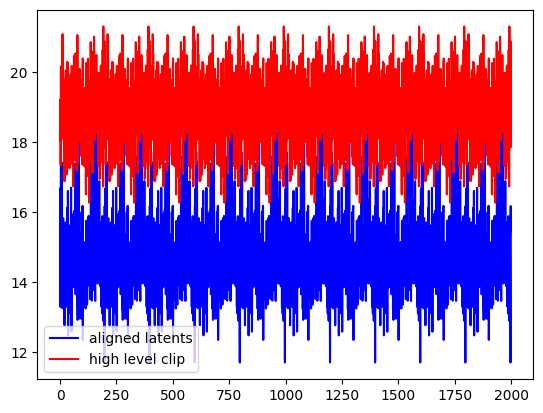

In [6]:
# Plot distribution of norms

import numpy as np
import matplotlib.pyplot as plt


aligned_latent_norms = all_aligned_latents.norm(p=2, dim=-1)
high_clip_norms = all_high_clip_latents.norm(p=2, dim=-1)

plt.plot(np.arange(aligned_latent_norms.shape[0]), aligned_latent_norms, c="blue", label="aligned latents")
plt.plot(np.arange(high_clip_norms.shape[0]), high_clip_norms, c="red", label="high level clip")
plt.legend()

# Alignment

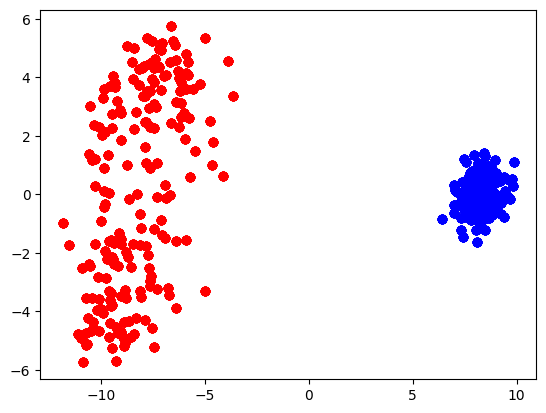

In [14]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

n = len(all_aligned_latents)
joint_latents = torch.cat((all_aligned_latents, all_high_clip_latents), dim=0)

pca = PCA(2)
joint_latents_lowdim = pca.fit_transform(joint_latents)
plt.scatter(joint_latents_lowdim[:n, 0], all_aligned_latents[:n, 1], c="blue", label="aligned latents")
plt.scatter(joint_latents_lowdim[n:, 0], joint_latents_lowdim[n:, 1], c="red", label="high level clip")

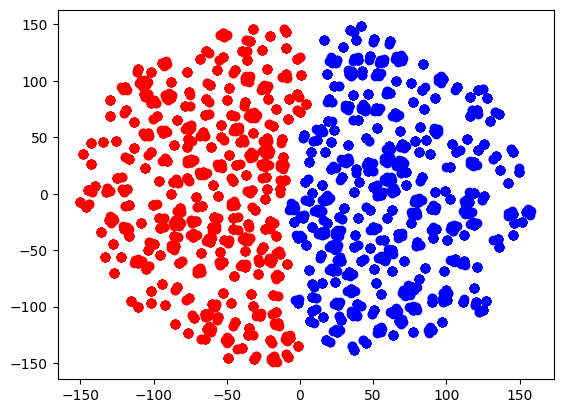

In [15]:
pca_hidden = PCA(50)
tsne = TSNE(2)

joint_latents_mid = pca_hidden.fit_transform(joint_latents)
joint_latents_low_tsne = tsne.fit_transform(joint_latents_mid)

plt.scatter(joint_latents_low_tsne[:n, 0], joint_latents_low_tsne[:n, 1], c="blue", label="aligned latents")
plt.scatter(joint_latents_low_tsne[n:, 0], joint_latents_low_tsne[n:, 1], c="red", label="high level clip")